In [11]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST
from tqdm.auto import tqdm
from IPython.display import HTML
from sklearn.manifold import TSNE
# from celluloid import Camera
from IPython.display import HTML

import os


### Seed Everything ###
torch.manual_seed(0)
torch.cuda.manual_seed(0)
np.random.seed(0)
random.seed(0)

tensor_transforms = transforms.Compose(
    [
        transforms.Resize((32,32)),
        transforms.ToTensor()
    ]
)
data_root = os.path.expanduser("~/data/mnist/")
os.makedirs(data_root, exist_ok=True)

train_set = MNIST(data_root, train=True, download=True, transform=tensor_transforms)
test_set = MNIST(data_root, train=False, download=True, transform=tensor_transforms)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [12]:
class VectorQuantizer(nn.Module):
    def __init__(self, codebook_dim=1024, latent_dim=8) -> None:
        super().__init__()

        self.codebook_dim = codebook_dim
        self.latent_dim = latent_dim

        self.codebook = nn.Embedding(codebook_dim, latent_dim)
        self.codebook.weight.data.uniform_(-1 / codebook_dim, 1 / codebook_dim)

    def forward(self, x):
        # x : (B, L, H, W) -> (B*H*W, L)

        batch_size = x.shape[0]
        H, W = x.shape[2], x.shape[3]
        x = x.permute(0, 2, 3, 1).contiguous().view(-1, self.latent_dim)


        L2 = torch.sum(x**2, dim=1, keepdim=True) #(B*H*W, 1)
        C2 = torch.sum(self.codebook.weight**2, dim=1).unsqueeze(0) #(1, K)
        CL = x@self.codebook.weight.t() #(B*H*W, K)
        
        distances = L2 - 2*CL + C2 #(B*H*W, K) broadcasting L2 & C2

        indices = torch.argmin(distances, dim=1) #(B*H*W,)

        encodings = torch.zeros(indices.shape[0], self.codebook_dim, device=x.device)
        encodings.scatter_(1, indices.unsqueeze(1), 1)
        avg_probs = torch.mean(encodings, dim=0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))

        z_q = self.codebook(indices)                              # (B*H*W, L)
        z_q = z_q.view(batch_size, H, W, self.latent_dim)         # (B, H, W, L)
        z_q = z_q.permute(0, 3, 1, 2).contiguous()

        return z_q, indices, perplexity


In [13]:
class ConvolutionalVectorQuantizedVAE(nn.Module):
    def __init__(self, in_channels=1, latent_dim=4, codebook_size=512):
        super().__init__()

        self.bottleneck = latent_dim
        self.in_channels = in_channels 
        self.codebook_size = codebook_size

        # result in a (B, C, H, W) of Z_e the output channels should match the latent dimension as both capture the same essence 
        
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=5, stride=2, padding=1, bias=False), 
            nn.BatchNorm2d(8),
            nn.ReLU(), 

            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=2, padding=1, bias=False), 
            nn.BatchNorm2d(16),
            nn.ReLU(), 

            nn.Conv2d(in_channels=16, out_channels=self.bottleneck, kernel_size=3, stride=2, padding=1, bias=False), 
            nn.BatchNorm2d(self.bottleneck),
            nn.ReLU(),
        )

        # quantize Z_e into the following Z_q of same dimensions i.e. (B, C, H, W)
        self.vq = VectorQuantizer(codebook_size, latent_dim)

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(in_channels=self.bottleneck, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(), 
            
            nn.ConvTranspose2d(in_channels=16, out_channels=8, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            
            nn.ConvTranspose2d(in_channels=8, out_channels=in_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
    

    def forward_enc(self, x):
        conv_enc = self.encoder_conv(x)
        return conv_enc

    def quantize(self, z):
        codes, indices, perplexity = self.vq(z)

        codebook_loss = torch.mean((codes - z.detach())**2)
        commitment_loss = torch.mean((codes.detach() - z)**2)

        codes = z + (codes - z).detach()
        
        return codes, codebook_loss, commitment_loss, perplexity

    def forward_dec(self, x):
        codes, codebook_loss, commitment_loss, perplexity = self.quantize(x)

        conv_dec = self.decoder_conv(codes)
        
        return codes, conv_dec, codebook_loss, commitment_loss, perplexity
        
    def forward(self, x):
        latents = self.forward_enc(x)
        quantized_latents, decoded, codebook_loss, commitment_loss, perplexity = self.forward_dec(latents)
        return latents, quantized_latents, decoded, codebook_loss, commitment_loss, perplexity

In [17]:
data_variance = torch.var(train_set.data/255.)
def train(model,
          train_set,
          test_set,
          batch_size,
          training_iterations,
          evaluation_iterations,
          beta=0.25):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    trainloader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
    testloader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0)

    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    def compute_loss(images):
        encoded, quantized_encoded, decoded, codebook_loss, commitment_loss, perplexity = model(images)
        recon_loss = torch.mean((images - decoded) ** 2) / data_variance
        loss = recon_loss + codebook_loss + beta * commitment_loss
        return loss, encoded, quantized_encoded, perplexity

    step_loss_buffer = []
    step_perplexity_buffer = []
    train_losses, evaluation_losses = [], []
    train_perplexities, evaluation_perplexities = [], []
    encoded_data_per_eval = []
    quantized_encoded_data_per_eval = []

    pbar = tqdm(total=training_iterations, position=0, leave=True)
    step_counter = 0
    training = True

    while training:
        for images, labels in trainloader:
            images = images.to(device)

            optimizer.zero_grad()
            loss, _, _, perplexity = compute_loss(images)
            loss.backward()
            optimizer.step()

            step_loss_buffer.append(loss.item())
            step_perplexity_buffer.append(perplexity.item())
            step_counter += 1
            pbar.update(1)
            pbar.set_postfix(loss=loss.item(), perplexity=perplexity.item())

            if step_counter % evaluation_iterations == 0:
                model.eval()
                encoded_evaluations = []
                quantized_encoded_evaluations = []
                eval_loss_buffer = []
                eval_perplexity_buffer = []

                with torch.no_grad():
                    for images, labels in testloader:
                        images = images.to(device)
                        loss, encoded, quantized_encoded, perplexity = compute_loss(images)
                        eval_loss_buffer.append(loss.item())
                        eval_perplexity_buffer.append(perplexity.item())

                        labels = labels.reshape(-1, 1)
                        encoded_evaluations.append(
                            torch.cat((encoded.cpu().flatten(1), labels), dim=-1)
                        )
                        quantized_encoded_evaluations.append(
                            torch.cat((quantized_encoded.cpu().flatten(1), labels), dim=-1)
                        )

                encoded_data_per_eval.append(torch.cat(encoded_evaluations).numpy())
                quantized_encoded_data_per_eval.append(torch.cat(quantized_encoded_evaluations).numpy())

                train_losses.append(np.mean(step_loss_buffer))
                evaluation_losses.append(np.mean(eval_loss_buffer))
                train_perplexities.append(np.mean(step_perplexity_buffer))
                evaluation_perplexities.append(np.mean(eval_perplexity_buffer))

                step_loss_buffer = []
                step_perplexity_buffer = []

                model.train()

            if step_counter >= training_iterations:
                training = False
                break

    print(f"Final Training Loss: {train_losses[-1]:.4f}")
    print(f"Final Evaluation Loss: {evaluation_losses[-1]:.4f}")
    print(f"Final Train Perplexity: {train_perplexities[-1]:.1f}")
    print(f"Final Eval Perplexity: {evaluation_perplexities[-1]:.1f}")

    return (model, train_losses, evaluation_losses,
            train_perplexities, evaluation_perplexities,
            encoded_data_per_eval, quantized_encoded_data_per_eval)

In [18]:
conv_vqvae = ConvolutionalVectorQuantizedVAE()

(conv_vqvae, train_losses, evaluation_losses,
            train_perplexities, evaluation_perplexities,
            encoded_data_per_eval, quantized_encoded_data_per_eval) = train(
    conv_vqvae,
    train_set=train_set,
    test_set=test_set,
    batch_size=64,
    training_iterations=25000,
    evaluation_iterations=250,
)

  0%|          | 0/25000 [00:00<?, ?it/s]

Final Training Loss: 0.1961
Final Evaluation Loss: 0.1966
Final Train Perplexity: 184.7
Final Eval Perplexity: 173.5


In [19]:
import pickle

torch.save(conv_vqvae.state_dict(), "conv_vqvae_state_dict.pt")

with open("train_history.pkl", "wb") as f:
    pickle.dump({
        "train_losses": train_losses,
        "evaluation_losses": evaluation_losses,
        "encoded_data_per_eval": encoded_data_per_eval,
        "quantized_encoded_data_per_eval": quantized_encoded_data_per_eval,
        "train_perplexities": train_perplexities,
        "evaluation_perplexities": evaluation_perplexities,
    }, f)

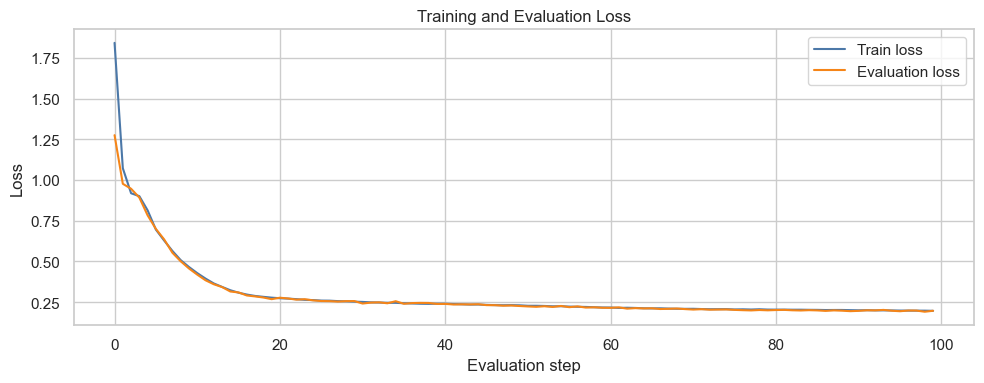

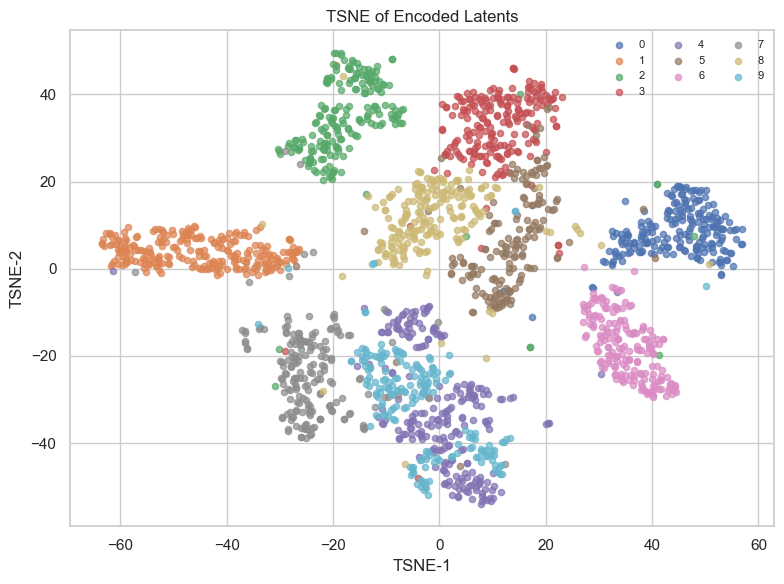

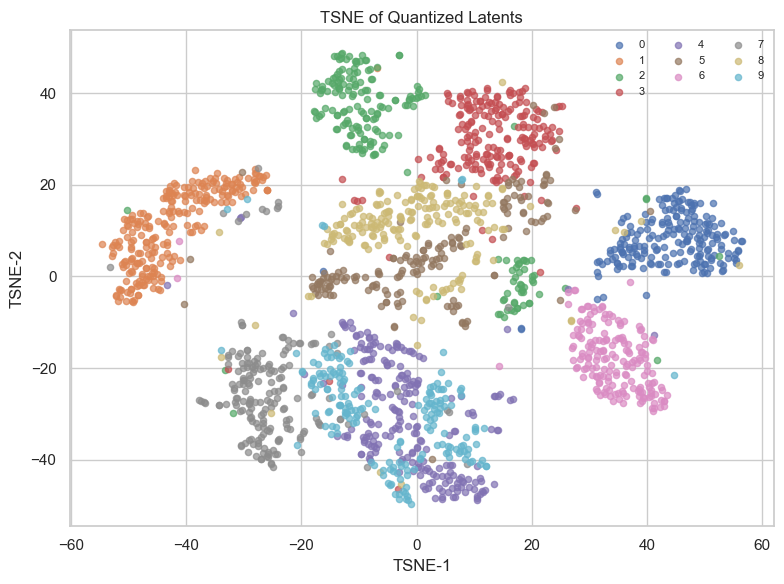

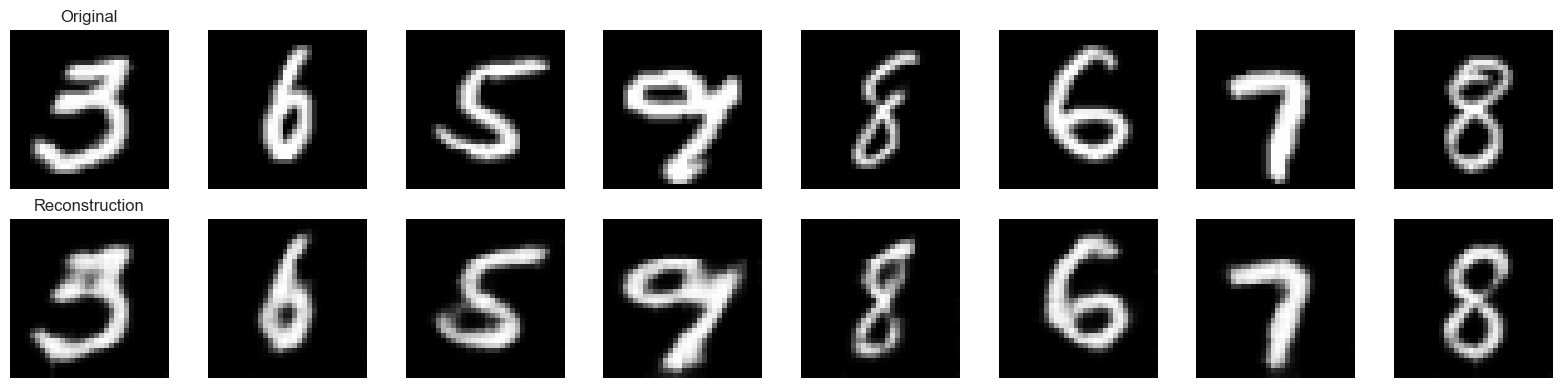

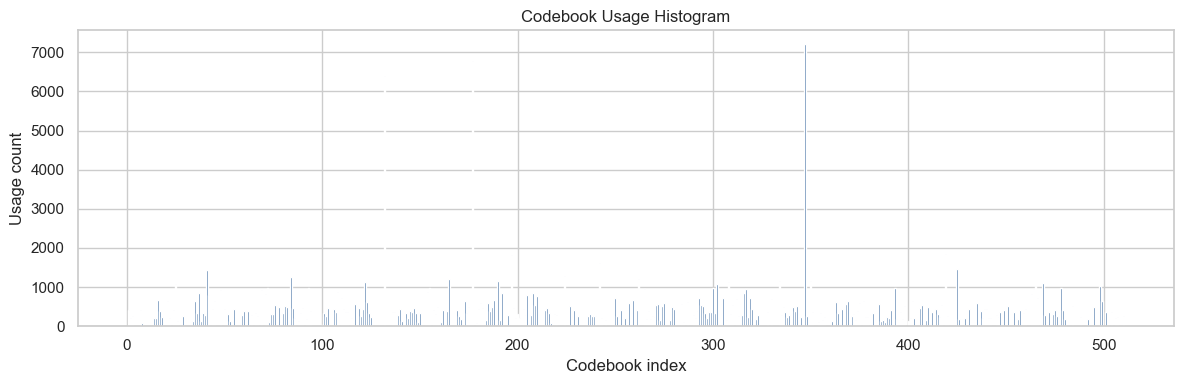

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.manifold import TSNE

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

train_losses = globals().get("train_losses", [])
evaluation_losses = globals().get("evaluation_losses", [])
encoded_data_per_eval = globals().get("encoded_data_per_eval", [])
quantized_encoded_data_per_eval = globals().get("quantized_encoded_data_per_eval", [])

if train_losses and evaluation_losses:
    plt.figure(figsize=(10, 4))
    plt.plot(train_losses, label="Train loss", color="#4C78A8")
    plt.plot(evaluation_losses, label="Evaluation loss", color="#F58518")
    plt.xlabel("Evaluation step")
    plt.ylabel("Loss")
    plt.title("Training and Evaluation Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

if encoded_data_per_eval and quantized_encoded_data_per_eval:
    last_encoded = encoded_data_per_eval[-1]
    last_quantized = quantized_encoded_data_per_eval[-1]
    labels = last_encoded[:, -1].astype(int)
    for name, features in [("Encoded", last_encoded[:, :-1]), ("Quantized", last_quantized[:, :-1])]:
        sample_size = min(2000, len(features))
        rng = np.random.RandomState(0)
        idx = rng.choice(len(features), size=sample_size, replace=False)
        X_sample = features[idx]
        y_sample = labels[idx]

        tsne = TSNE(n_components=2, random_state=0, perplexity=min(30, sample_size - 1))
        embeddings = tsne.fit_transform(X_sample)

        plt.figure(figsize=(8, 6))
        for label in np.unique(y_sample):
            mask = y_sample == label
            plt.scatter(embeddings[mask, 0], embeddings[mask, 1], s=20, alpha=0.7, label=str(label))
        plt.title(f"TSNE of {name} Latents")
        plt.xlabel("TSNE-1")
        plt.ylabel("TSNE-2")
        plt.legend(ncols=3, fontsize=8, frameon=False)
        plt.tight_layout()
        plt.show()

if os.path.exists("conv_vqvae_state_dict.pt"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = ConvolutionalVectorQuantizedVAE().to(device)
    model.load_state_dict(torch.load("conv_vqvae_state_dict.pt", map_location=device))
    model.eval()

    sample_loader = DataLoader(test_set, batch_size=8, shuffle=True, num_workers=0)
    images, _ = next(iter(sample_loader))
    images = images.to(device)

    with torch.no_grad():
        latents, quantized_latents, reconstructions, _, _, _ = model(images)

    images_cpu = images.cpu().numpy()
    reconstructions_cpu = reconstructions.cpu().numpy()
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i in range(8):
        axes[0, i].imshow(images_cpu[i, 0], cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(reconstructions_cpu[i, 0], cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_title("Original")
    axes[1, 0].set_title("Reconstruction")
    plt.tight_layout()
    plt.show()

    codebook_size = model.codebook_size
    usage_loader = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=0)
    all_indices = []
    with torch.no_grad():
        for batch_images, _ in usage_loader:
            batch_images = batch_images.to(device)
            latents = model.forward_enc(batch_images)
            _, indices, _ = model.vq(latents)
            all_indices.append(indices.cpu().numpy())

    indices = np.concatenate(all_indices)
    counts = np.bincount(indices, minlength=codebook_size)
    used_codes = counts > 0
    plt.figure(figsize=(12, 4))
    plt.bar(np.arange(codebook_size)[used_codes], counts[used_codes], color="#4C78A8")
    plt.xlabel("Codebook index")
    plt.ylabel("Usage count")
    plt.title("Codebook Usage Histogram")
    plt.tight_layout()
    plt.show()

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X = quantized_encoded_data_per_eval[-1][:, :-1]   # last eval snapshot, drop label col
y = quantized_encoded_data_per_eval[-1][:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
print("kNN accuracy on quantized latents:", knn.score(X_test, y_test))

kNN accuracy on quantized latents: 0.9446666666666667


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X = encoded_data_per_eval[-1][:, :-1]   # last eval snapshot, drop label col
y = encoded_data_per_eval[-1][:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
print("kNN accuracy on encoded latents:", knn.score(X_test, y_test))

kNN accuracy on encoded latents: 0.957


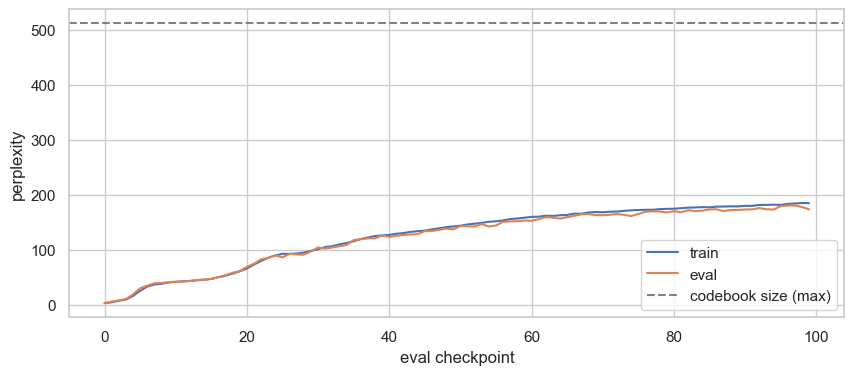

In [23]:
plt.plot(train_perplexities, label="train")
plt.plot(evaluation_perplexities, label="eval")
plt.axhline(y=512, color="gray", linestyle="--", label="codebook size (max)")
plt.xlabel("eval checkpoint")
plt.ylabel("perplexity")
plt.legend()